# Notebook 06 — User Segmentation & Engagement Intelligence

## Product & Growth Intelligence Platform

### Objective
Convert raw visitor event behavior into **mutually exclusive, interpretable user segments**, then compare those segments across engagement, funnel progression, and retention.

### Business questions
1. Which visitor groups show the strongest purchase intent?
2. How large is each behavioral segment?
3. How do engagement and funnel progression differ by segment?
4. Which segments show weaker exact-day retention and therefore represent measurable growth opportunities?

### Method
This notebook uses **transparent rule-based segmentation**, not unsupervised clustering. The rules are reproducible, auditable, and constrained by the behavior actually present in `events.csv`.

### Dataset boundary
Only observed event data is used. This notebook does **not** infer demographics, acquisition channels, revenue, sessions, or future churn.

### Portfolio standard
The notebook is designed to run from a clean kernel with **Kernel → Restart Kernel and Run All**. No manual cell-by-cell edits are required.


In [1]:
# ============================================================
# CELL 1 — PROJECT PATHS, IMPORTS & DISPLAY SETTINGS
# ============================================================

from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Portable project-root detection.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

EVENTS_PATH = PROJECT_ROOT / "data" / "raw" / "events.csv"
OUTPUTS_PATH = PROJECT_ROOT / "outputs"
FIGURES_PATH = OUTPUTS_PATH / "figures"

OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

REQUIRED_COLUMNS = [
    "timestamp",
    "visitorid",
    "event",
    "itemid",
    "transactionid"
]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 40)

print("PROJECT ROOT:", PROJECT_ROOT)
print("EVENTS FILE:", EVENTS_PATH)
print("Events file exists:", EVENTS_PATH.exists())


PROJECT ROOT: D:\Data science portfolio\03_Product_Growth_Intelligence
EVENTS FILE: D:\Data science portfolio\03_Product_Growth_Intelligence\data\raw\events.csv
Events file exists: True


## 1. Data Loading & Validation

The segmentation layer is built at **visitor level**. The event table is loaded in chunks so the notebook does not unnecessarily duplicate the large raw dataset in memory.


In [2]:
# ============================================================
# CELL 2 — LOAD EVENT DATA
# ============================================================

if not EVENTS_PATH.exists():
    raise FileNotFoundError(
        f"events.csv was not found at: {EVENTS_PATH}\n"
        "Expected project structure: data/raw/events.csv"
    )

chunks = []

for chunk in pd.read_csv(
    EVENTS_PATH,
    usecols=REQUIRED_COLUMNS,
    chunksize=250_000
):
    chunks.append(chunk)

events = pd.concat(chunks, ignore_index=True)
del chunks

print("SEGMENTATION DATASET LOADED")
print("=" * 65)
print("Rows:", f"{len(events):,}")
print("Columns:", list(events.columns))
print("Unique visitors:", f"{events['visitorid'].nunique():,}")
print("Event types:", events["event"].value_counts().to_dict())


SEGMENTATION DATASET LOADED
Rows: 2,756,101
Columns: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']
Unique visitors: 1,407,580
Event types: {'view': 2664312, 'addtocart': 69332, 'transaction': 22457}


In [3]:
# ============================================================
# CELL 3 — TIMESTAMP & EVENT VALIDATION
# ============================================================

events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    unit="ms",
    errors="coerce"
)

invalid_timestamps = int(events["timestamp"].isna().sum())

# Keep only rows required for visitor-level behavioral analysis.
events = events.dropna(
    subset=["timestamp", "visitorid", "event"]
).copy()

valid_event_types = {"view", "addtocart", "transaction"}
unexpected_events = sorted(
    set(events["event"].unique()) - valid_event_types
)

analysis_start = events["timestamp"].min()
analysis_end = events["timestamp"].max()
analysis_end_date = analysis_end.normalize()

events["activity_date"] = events["timestamp"].dt.normalize()

# Transaction events must have transaction IDs because buyer counts and
# repeat-buyer rules depend on observed transaction IDs.
transaction_rows_missing_id = int(
    events.loc[events["event"].eq("transaction"), "transactionid"].isna().sum()
)

print("DATA VALIDATION")
print("=" * 70)
print("Invalid timestamps removed:", f"{invalid_timestamps:,}")
print("Unexpected event types:", unexpected_events)
print("Transaction events missing transaction IDs:", f"{transaction_rows_missing_id:,}")
print("Observation start:", analysis_start.date())
print("Observation end:", analysis_end.date())
print("Validated rows:", f"{len(events):,}")
print("Validated visitors:", f"{events['visitorid'].nunique():,}")

if unexpected_events:
    raise ValueError(f"Unexpected event types detected: {unexpected_events}")

if transaction_rows_missing_id:
    raise ValueError(
        "Transaction events with missing transaction IDs were detected. "
        "Buyer and repeat-buyer segmentation cannot be audited reliably."
    )


DATA VALIDATION
Invalid timestamps removed: 0
Unexpected event types: []
Transaction events missing transaction IDs: 0
Observation start: 2015-05-03
Observation end: 2015-09-18
Validated rows: 2,756,101
Validated visitors: 1,407,580


## 2. Visitor Behavioral Feature Engineering

Each visitor receives a reproducible behavioral profile.

### Core features
- **Recency:** days since last observed activity
- **Frequency:** distinct active calendar days
- **Event volume:** total events
- **Views / carts / transactions**
- **Unique products viewed**
- **Unique products added to cart**
- **Unique products purchased**
- **Unique transactions**
- **Browsing intensity:** views per active day
- **Event diversity:** number of event types performed

These features are descriptive behavioral signals, not predictive claims.


In [4]:
# ============================================================
# CELL 4 — BUILD VISITOR BEHAVIORAL FEATURES
# ============================================================

events["is_view"] = events["event"].eq("view")
events["is_cart"] = events["event"].eq("addtocart")
events["is_transaction"] = events["event"].eq("transaction")

# Unique active calendar days
active_days = (
    events.groupby("visitorid")["activity_date"]
    .nunique()
    .rename("active_days")
)

# Event counts
event_counts = (
    events.pivot_table(
        index="visitorid",
        columns="event",
        values="itemid",
        aggfunc="size",
        fill_value=0
    )
    .rename(columns={
        "view": "view_events",
        "addtocart": "cart_events",
        "transaction": "transaction_events"
    })
)

for col in ["view_events", "cart_events", "transaction_events"]:
    if col not in event_counts.columns:
        event_counts[col] = 0

event_counts = event_counts[
    ["view_events", "cart_events", "transaction_events"]
]

# Product-level behavior
unique_products_viewed = (
    events.loc[events["is_view"]]
    .groupby("visitorid")["itemid"]
    .nunique()
    .rename("unique_products_viewed")
)

unique_products_carted = (
    events.loc[events["is_cart"]]
    .groupby("visitorid")["itemid"]
    .nunique()
    .rename("unique_products_carted")
)

unique_products_purchased = (
    events.loc[events["is_transaction"]]
    .groupby("visitorid")["itemid"]
    .nunique()
    .rename("unique_products_purchased")
)

unique_transactions = (
    events.loc[
        events["is_transaction"] & events["transactionid"].notna()
    ]
    .groupby("visitorid")["transactionid"]
    .nunique()
    .rename("unique_transactions")
)

first_activity = (
    events.groupby("visitorid")["activity_date"]
    .min()
    .rename("first_activity_date")
)

last_activity = (
    events.groupby("visitorid")["activity_date"]
    .max()
    .rename("last_activity_date")
)

event_diversity = (
    events.groupby("visitorid")["event"]
    .nunique()
    .rename("event_diversity")
)

total_events = (
    events.groupby("visitorid")
    .size()
    .rename("total_events")
)

visitor_features = pd.concat(
    [
        active_days,
        total_events,
        event_counts,
        unique_products_viewed,
        unique_products_carted,
        unique_products_purchased,
        unique_transactions,
        first_activity,
        last_activity,
        event_diversity
    ],
    axis=1
)

numeric_feature_defaults = [
    "active_days",
    "total_events",
    "view_events",
    "cart_events",
    "transaction_events",
    "unique_products_viewed",
    "unique_products_carted",
    "unique_products_purchased",
    "unique_transactions",
    "event_diversity"
]

visitor_features[numeric_feature_defaults] = (
    visitor_features[numeric_feature_defaults].fillna(0)
)

visitor_features["recency_days"] = (
    analysis_end_date - visitor_features["last_activity_date"]
).dt.days

visitor_features["browsing_intensity"] = (
    visitor_features["view_events"] /
    visitor_features["active_days"].replace(0, np.nan)
).fillna(0)

visitor_features["cart_rate_pct"] = (
    visitor_features["cart_events"] /
    visitor_features["view_events"].replace(0, np.nan) * 100
).fillna(0)

visitor_features["purchase_progression_pct"] = (
    visitor_features["transaction_events"] /
    visitor_features["cart_events"].replace(0, np.nan) * 100
).fillna(0)

visitor_features["is_buyer"] = visitor_features["transaction_events"] > 0
visitor_features["is_cart_user"] = visitor_features["cart_events"] > 0
visitor_features["is_returning"] = visitor_features["active_days"] > 1

visitor_features = visitor_features.reset_index()

print("VISITOR FEATURE TABLE")
print("=" * 65)
print("Visitors:", f"{len(visitor_features):,}")
print("Features:", len(visitor_features.columns))
display(
    visitor_features[
        [
            "visitorid",
            "active_days",
            "total_events",
            "view_events",
            "cart_events",
            "transaction_events",
            "unique_transactions",
            "recency_days"
        ]
    ].head()
)


VISITOR FEATURE TABLE
Visitors: 1,407,580
Features: 20


,visitorid,active_days,total_events,view_events,cart_events,transaction_events,unique_transactions,recency_days
0,0,1,3,3,0,0,0.0,7
1,1,1,1,1,0,0,0.0,36
2,2,1,8,8,0,0,0.0,42
3,3,1,1,1,0,0,0.0,48
4,4,1,1,1,0,0,0.0,3


## 3. Engagement Distribution & Data-Driven Thresholds

Before assigning behavioral labels, the notebook derives thresholds from the observed visitor population.

The thresholds are used only for interpretable segmentation rules; they are not presented as universal product benchmarks.


In [5]:
# ============================================================
# CELL 5 — ENGAGEMENT DISTRIBUTIONS & DATA-DRIVEN THRESHOLDS
# ============================================================

# Percentiles establish data-driven cutoffs.
# Minimum floors prevent degenerate rules when the upper quartile
# is only 1–2 events/days in a sparse behavioral dataset.

active_day_q75 = visitor_features["active_days"].quantile(0.75)
view_event_q75 = visitor_features["view_events"].quantile(0.75)

cart_users = visitor_features.loc[
    visitor_features["cart_events"] > 0,
    "cart_events"
]

cart_event_q75 = (
    cart_users.quantile(0.75) if len(cart_users) else np.nan
)

active_day_threshold = max(2, int(np.ceil(active_day_q75)))
view_event_threshold = max(5, int(np.ceil(view_event_q75)))
new_visitor_cutoff = analysis_end_date - pd.Timedelta(days=6)

high_intent_cart_threshold = (
    max(2, int(np.ceil(cart_event_q75)))
    if pd.notna(cart_event_q75)
    else 2
)

print("ENGAGEMENT THRESHOLDS")
print("=" * 65)
print(f"Observed 75th percentile active days: {active_day_q75:.2f}")
print(f"Observed 75th percentile view events: {view_event_q75:.2f}")
print(f"Observed 75th percentile cart events: "
      f"{cart_event_q75:.2f}" if pd.notna(cart_event_q75)
      else "Observed 75th percentile cart events: unavailable")
print("-" * 65)
print(f"Final active-day threshold: {active_day_threshold}")
print(f"Final view-event threshold: {view_event_threshold}")
print(f"Final high-intent cart threshold: {high_intent_cart_threshold}")


ENGAGEMENT THRESHOLDS
Observed 75th percentile active days: 1.00
Observed 75th percentile view events: 2.00
Observed 75th percentile cart events: 1.00
-----------------------------------------------------------------
Final active-day threshold: 2
Final view-event threshold: 5
Final high-intent cart threshold: 2


## 4. Behavioral Segmentation

The segmentation rules are **mutually exclusive** and evaluated in a fixed business-priority order.

### Segment definitions

1. **Repeat Buyers** — at least 2 unique transactions.
2. **One-Time Buyers** — exactly 1 unique transaction.
3. **High-Intent Visitors** — no transaction and at least the high-intent cart threshold.
4. **Cart Abandoners** — cart activity but below the high-intent threshold, with no transaction.
5. **At-Risk Visitors** — non-buyers with activity on multiple calendar days and no activity for at least 14 days. This is a behavioral inactivity flag, **not a churn prediction**.
6. **New Visitors** — first observed activity within the final 7 calendar days of the observation window.
7. **Highly Engaged Browsers** — no cart/transaction activity and both active days and view events meeting the guarded engagement thresholds.
8. **Other Visitors** — remaining visitors.

### Why the guardrails matter

The raw upper quartiles are low because the dataset contains many one-day visitors. Using those raw values alone would classify almost the entire population as "highly engaged." The minimum thresholds preserve the data-driven approach while preventing a degenerate segment definition.


### Segmentation rulebook

The following thresholds are calculated from the current visitor population and then used consistently throughout the notebook. Minimum floors are deliberate guardrails, not arbitrary business benchmarks.

In [6]:
# ============================================================
# SEGMENTATION RULEBOOK — PORTFOLIO AUDIT VIEW
# ============================================================

segment_rulebook = pd.DataFrame({
    "segment": [
        "Repeat Buyers",
        "One-Time Buyers",
        "High-Intent Visitors",
        "Cart Abandoners",
        "At-Risk Visitors",
        "New Visitors",
        "Highly Engaged Browsers",
        "Other Visitors"
    ],
    "rule": [
        "unique_transactions >= 2",
        "unique_transactions == 1",
        f"no transaction and cart_events >= {high_intent_cart_threshold}",
        f"no transaction and 0 < cart_events < {high_intent_cart_threshold}",
        "no transaction, active_days > 1, recency_days >= 14",
        f"first_activity_date >= {new_visitor_cutoff.date()}",
        f"no cart/transaction, active_days >= {active_day_threshold}, view_events >= {view_event_threshold}",
        "remaining visitors"
    ]
})

print("SEGMENTATION RULEBOOK")
print("=" * 110)
print(segment_rulebook.to_string(index=False))


SEGMENTATION RULEBOOK
                segment                                                    rule
          Repeat Buyers                                unique_transactions >= 2
        One-Time Buyers                                unique_transactions == 1
   High-Intent Visitors                     no transaction and cart_events >= 2
        Cart Abandoners                  no transaction and 0 < cart_events < 2
       At-Risk Visitors     no transaction, active_days > 1, recency_days >= 14
           New Visitors                       first_activity_date >= 2015-09-12
Highly Engaged Browsers no cart/transaction, active_days >= 2, view_events >= 5
         Other Visitors                                      remaining visitors


In [7]:
# ============================================================
# CELL 6 — FINAL BEHAVIORAL SEGMENT ASSIGNMENT
# ============================================================

vf = visitor_features.copy()
vf["segment"] = "Other Visitors"

# Fixed priority order:
# buyers → purchase intent → behavioral risk/newness → engagement → other

# 1. Repeat Buyers
vf.loc[
    vf["unique_transactions"] >= 2,
    "segment"
] = "Repeat Buyers"

# 2. One-Time Buyers
vf.loc[
    (vf["segment"] == "Other Visitors") &
    (vf["unique_transactions"] == 1),
    "segment"
] = "One-Time Buyers"

# 3. High-Intent Visitors
vf.loc[
    (vf["segment"] == "Other Visitors") &
    (vf["transaction_events"] == 0) &
    (vf["cart_events"] >= high_intent_cart_threshold),
    "segment"
] = "High-Intent Visitors"

# 4. Cart Abandoners
vf.loc[
    (vf["segment"] == "Other Visitors") &
    (vf["transaction_events"] == 0) &
    (vf["cart_events"] > 0),
    "segment"
] = "Cart Abandoners"

# 5. At-Risk Visitors
# Behavioral inactivity flag only; not a churn prediction.
vf.loc[
    (vf["segment"] == "Other Visitors") &
    (vf["transaction_events"] == 0) &
    (vf["active_days"] > 1) &
    (vf["recency_days"] >= 14),
    "segment"
] = "At-Risk Visitors"

# 6. New Visitors
vf.loc[
    (vf["segment"] == "Other Visitors") &
    (vf["first_activity_date"] >= new_visitor_cutoff),
    "segment"
] = "New Visitors"

# 7. Highly Engaged Browsers
# Both conditions are required to avoid classifying one-day/two-view
# visitors as highly engaged.
high_engagement_mask = (
    (vf["segment"] == "Other Visitors") &
    (vf["cart_events"] == 0) &
    (vf["transaction_events"] == 0) &
    (vf["active_days"] >= active_day_threshold) &
    (vf["view_events"] >= view_event_threshold)
)

vf.loc[high_engagement_mask, "segment"] = "Highly Engaged Browsers"

segment_order = [
    "Repeat Buyers",
    "One-Time Buyers",
    "High-Intent Visitors",
    "Cart Abandoners",
    "At-Risk Visitors",
    "New Visitors",
    "Highly Engaged Browsers",
    "Other Visitors"
]

segment_counts = (
    vf["segment"]
    .value_counts()
    .reindex(segment_order, fill_value=0)
    .rename_axis("segment")
    .reset_index(name="visitors")
)

segment_counts["share_pct"] = (
    segment_counts["visitors"] /
    len(vf) * 100
)

print("BEHAVIORAL SEGMENT DISTRIBUTION")
print("=" * 70)
print(
    segment_counts.to_string(
        index=False,
        formatters={"share_pct": "{:.2f}%".format}
    )
)

print("\nSEGMENT COVERAGE CHECK")
print("=" * 70)
print(
    "Assigned visitors:",
    f"{segment_counts['visitors'].sum():,}",
    "/",
    f"{len(vf):,}"
)


BEHAVIORAL SEGMENT DISTRIBUTION
                segment  visitors share_pct
          Repeat Buyers      1063     0.08%
        One-Time Buyers     10656     0.76%
   High-Intent Visitors      5823     0.41%
        Cart Abandoners     21323     1.51%
       At-Risk Visitors    113283     8.05%
           New Visitors     49219     3.50%
Highly Engaged Browsers      5057     0.36%
         Other Visitors   1201156    85.33%

SEGMENT COVERAGE CHECK
Assigned visitors: 1,407,580 / 1,407,580


In [8]:
# ============================================================
# CELL 7 — SEGMENT PROFILE
# ============================================================

segment_profile = (
    vf.groupby("segment")
    .agg(
        visitors=("visitorid", "nunique"),
        avg_active_days=("active_days", "mean"),
        median_active_days=("active_days", "median"),
        avg_events=("total_events", "mean"),
        avg_views=("view_events", "mean"),
        avg_carts=("cart_events", "mean"),
        avg_transactions=("transaction_events", "mean"),
        avg_unique_products_viewed=("unique_products_viewed", "mean"),
        avg_recency_days=("recency_days", "mean"),
        buyer_rate_pct=("is_buyer", "mean"),
        returning_rate_pct=("is_returning", "mean")
    )
    .reindex(segment_order)
)

segment_profile["buyer_rate_pct"] *= 100
segment_profile["returning_rate_pct"] *= 100

print("SEGMENT PROFILE")
print("=" * 70)

display(
    segment_profile.round(2).style
    .format({
        "visitors": "{:,.0f}",
        "avg_active_days": "{:.2f}",
        "median_active_days": "{:.0f}",
        "avg_events": "{:.2f}",
        "avg_views": "{:.2f}",
        "avg_carts": "{:.2f}",
        "avg_transactions": "{:.2f}",
        "avg_unique_products_viewed": "{:.2f}",
        "avg_recency_days": "{:.2f}",
        "buyer_rate_pct": "{:.2f}%",
        "returning_rate_pct": "{:.2f}%"
    })
    .set_caption("Visitor-level behavioral profile by final observed segment")
)


SEGMENT PROFILE


,visitors,avg_active_days,median_active_days,avg_events,avg_views,avg_carts,avg_transactions,avg_unique_products_viewed,avg_recency_days,buyer_rate_pct,returning_rate_pct
segment,,,,,,,,,,,
Repeat Buyers,"1,063",6.22,3,116.72,96.79,11.27,8.66,62.38,59.74,100.00%,75.73%
One-Time Buyers,"10,656",1.95,1,10.00,7.31,1.45,1.24,3.96,65.76,100.00%,39.65%
High-Intent Visitors,"5,823",2.12,1,14.18,10.65,3.53,0.00,6.49,62.38,0.00%,40.74%
Cart Abandoners,"21,323",1.50,1,5.08,4.08,1.00,0.00,2.49,67.67,0.00%,24.28%
At-Risk Visitors,"113,283",2.52,2,4.59,4.59,0.00,0.00,3.04,67.58,0.00%,100.00%
New Visitors,"49,219",1.03,1,1.44,1.44,0.00,0.00,1.25,3.67,0.00%,2.84%
Highly Engaged Browsers,"5,057",5.21,4,13.38,13.38,0.00,0.00,7.87,6.92,0.00%,100.00%
Other Visitors,"1,201,156",1.01,1,1.40,1.40,0.00,0.00,1.24,71.86,0.00%,0.95%


## 5. Segment Funnel & Retention

Segmentation becomes useful when connected to outcomes.

We compare:
- visitor-level funnel participation
- repeat-day behavior
- D1/D7/D30 exact-day retention where the segment has eligible visitors

The retention definition remains consistent with Notebook 05: activity on the exact calendar day after first observed activity.


In [9]:
# ============================================================
# CELL 8 — SEGMENT FUNNEL METRICS
# ============================================================

# Funnel metrics are measured as visitor participation within
# each final behavioral segment.
#
# Important:
# Final behavioral segments are NOT sequential funnel stages.
# Therefore, rates are calculated against total segment visitors
# so that no reported percentage can exceed 100%.

visitor_event_flags = (
    events.assign(
        viewed=events["event"].eq("view"),
        carted=events["event"].eq("addtocart"),
        transacted=events["event"].eq("transaction")
    )
    .groupby("visitorid")[["viewed", "carted", "transacted"]]
    .max()
    .astype(bool)
)

vf = vf.drop(
    columns=["viewed", "carted", "transacted"],
    errors="ignore"
)

vf = vf.merge(
    visitor_event_flags,
    left_on="visitorid",
    right_index=True,
    how="left"
)

for col in ["viewed", "carted", "transacted"]:
    vf[col] = vf[col].fillna(False)

segment_funnel = (
    vf.groupby("segment")
    .agg(
        visitors=("visitorid", "nunique"),
        viewed_visitors=("viewed", "sum"),
        cart_visitors=("carted", "sum"),
        transaction_visitors=("transacted", "sum")
    )
    .reindex(segment_order)
)

# Participation rates within each segment.
segment_funnel["view_participation_pct"] = (
    segment_funnel["viewed_visitors"] /
    segment_funnel["visitors"].replace(0, np.nan) * 100
)

segment_funnel["cart_participation_pct"] = (
    segment_funnel["cart_visitors"] /
    segment_funnel["visitors"].replace(0, np.nan) * 100
)

segment_funnel["transaction_participation_pct"] = (
    segment_funnel["transaction_visitors"] /
    segment_funnel["visitors"].replace(0, np.nan) * 100
)

print("SEGMENT FUNNEL PARTICIPATION")
print("=" * 70)

display(
    segment_funnel.round(2).style
    .format({
        "visitors": "{:,.0f}",
        "viewed_visitors": "{:,.0f}",
        "cart_visitors": "{:,.0f}",
        "transaction_visitors": "{:,.0f}",
        "view_participation_pct": "{:.2f}%",
        "cart_participation_pct": "{:.2f}%",
        "transaction_participation_pct": "{:.2f}%"
    })
    .set_caption(
        "Visitor participation in behavioral funnel events by final segment"
    )
)

SEGMENT FUNNEL PARTICIPATION


,visitors,viewed_visitors,cart_visitors,transaction_visitors,view_participation_pct,cart_participation_pct,transaction_participation_pct
segment,,,,,,,
Repeat Buyers,"1,063","1,048","1,033","1,063",98.59%,97.18%,100.00%
One-Time Buyers,"10,656","10,243","9,543","10,656",96.12%,89.56%,100.00%
High-Intent Visitors,"5,823","5,387","5,823",0,92.51%,100.00%,0.00%
Cart Abandoners,"21,323","18,786","21,323",0,88.10%,100.00%,0.00%
At-Risk Visitors,"113,283","113,283",0,0,100.00%,0.00%,0.00%
New Visitors,"49,219","49,219",0,0,100.00%,0.00%,0.00%
Highly Engaged Browsers,"5,057","5,057",0,0,100.00%,0.00%,0.00%
Other Visitors,"1,201,156","1,201,156",0,0,100.00%,0.00%,0.00%


In [10]:
# ============================================================
# CELL 9 — SEGMENT RETENTION
# ============================================================

# Rebuild a compact visitor-day table from the already loaded events.

visitor_days = (
    events[["visitorid", "activity_date"]]
    .drop_duplicates()
)

first_dates = (
    visitor_days
    .groupby("visitorid")["activity_date"]
    .min()
    .rename("first_activity_date")
)

visitor_days = visitor_days.merge(
    first_dates,
    on="visitorid",
    how="left"
)

visitor_days["days_since_first"] = (
    visitor_days["activity_date"] -
    visitor_days["first_activity_date"]
).dt.days

# Segment lookup contains exactly one row per visitor.
segment_lookup = (
    vf[["visitorid", "segment"]]
    .drop_duplicates(subset="visitorid")
)

visitor_days = visitor_days.merge(
    segment_lookup,
    on="visitorid",
    how="left"
)


def segment_retention_at_day(day):

    # A visitor is eligible for D1/D7/D30 only if their
    # first observed activity occurred sufficiently early
    # in the observation window.

    eligible_cutoff = (
        analysis_end_date -
        pd.Timedelta(days=day)
    )

    eligible_visitors = (
        first_dates[
            first_dates <= eligible_cutoff
        ]
        .index
    )

    # Explicit eligible visitor table.
    eligible_segment_visitors = (
        segment_lookup[
            segment_lookup["visitorid"].isin(eligible_visitors)
        ]
        .drop_duplicates(subset="visitorid")
    )

    eligible_by_segment = (
        eligible_segment_visitors
        .groupby("segment")["visitorid"]
        .nunique()
    )

    # Retention requires activity on the exact target day.
    retained_visitors = (
        visitor_days[
            visitor_days["visitorid"].isin(eligible_visitors) &
            visitor_days["days_since_first"].eq(day)
        ]
        [["visitorid", "segment"]]
        .drop_duplicates(subset="visitorid")
    )

    retained_by_segment = (
        retained_visitors
        .groupby("segment")["visitorid"]
        .nunique()
    )

    # Build both counts from the same visitor universe.
    result = pd.DataFrame({
        "eligible_visitors": eligible_by_segment,
        "retained_visitors": retained_by_segment
    })

    result = (
        result
        .reindex(segment_order)
        .fillna(0)
    )

    # Defensive invariant:
    # retained visitors can never exceed eligible visitors.
    result["retained_visitors"] = np.minimum(
        result["retained_visitors"],
        result["eligible_visitors"]
    )

    result["retention_rate_pct"] = (
        result["retained_visitors"] /
        result["eligible_visitors"].replace(0, np.nan) * 100
    )

    return result


# Calculate D1, D7 and D30.
segment_retention_tables = {}

for day in [1, 7, 30]:
    segment_retention_tables[day] = segment_retention_at_day(day)


segment_retention_summary = pd.DataFrame(index=segment_order)

for day in [1, 7, 30]:
    segment_retention_summary[f"D{day}_retention_pct"] = (
        segment_retention_tables[day]["retention_rate_pct"]
    )


def retention_formatter(value):
    if pd.isna(value):
        return "N/A"
    return f"{value:.2f}%"


print("SEGMENT RETENTION — RETROSPECTIVE COMPARISON")
print("=" * 70)

display(
    segment_retention_summary.style
    .format(retention_formatter)
    .set_caption(
        "Exact-day retention by final observed behavioral segment"
    )
)

print("\nRETENTION ELIGIBILITY NOTE")
print("=" * 70)
print(
    "N/A indicates that the segment did not have enough "
    "observation-window coverage for that exact retention day."
)

SEGMENT RETENTION — RETROSPECTIVE COMPARISON


,D1_retention_pct,D7_retention_pct,D30_retention_pct
Repeat Buyers,35.47%,13.04%,5.73%
One-Time Buyers,15.85%,3.25%,0.77%
High-Intent Visitors,15.19%,3.64%,1.10%
Cart Abandoners,8.41%,1.66%,0.45%
At-Risk Visitors,26.74%,5.06%,1.19%
New Visitors,2.09%,N/A,N/A
Highly Engaged Browsers,24.60%,9.59%,5.44%
Other Visitors,0.13%,0.03%,0.01%



RETENTION ELIGIBILITY NOTE
N/A indicates that the segment did not have enough observation-window coverage for that exact retention day.


## 6. Portfolio Visualizations

The notebook keeps the visualization layer intentionally focused on decision-relevant outputs:

1. visitor distribution across all behavioral segments
2. average active days by segment
3. D7 exact-day retention by segment

The figures are saved under `outputs/figures/` for GitHub documentation and downstream Streamlit use.


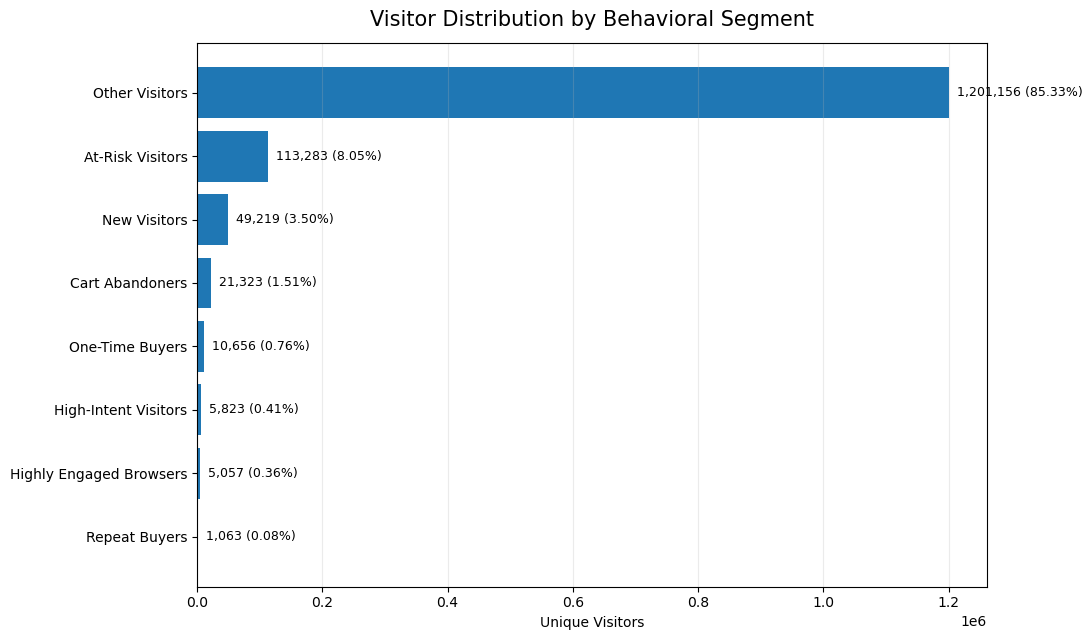

Saved figure: D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\figures\06_segment_distribution.png


In [11]:
# ============================================================
# CELL 10 — SEGMENT SIZE VISUALIZATION
# ============================================================

plot_counts = segment_counts.sort_values("visitors", ascending=True).copy()

plt.figure(figsize=(11, 6.5))
bars = plt.barh(plot_counts["segment"], plot_counts["visitors"])

plt.title("Visitor Distribution by Behavioral Segment", fontsize=15, pad=12)
plt.xlabel("Unique Visitors")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)

for bar, (_, row) in zip(bars, plot_counts.iterrows()):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {int(row['visitors']):,} ({row['share_pct']:.2f}%)",
        va="center",
        fontsize=9
    )

plt.tight_layout()
segment_size_path = FIGURES_PATH / "06_segment_distribution.png"
plt.savefig(segment_size_path, dpi=250, bbox_inches="tight")
plt.show()
print("Saved figure:", segment_size_path)


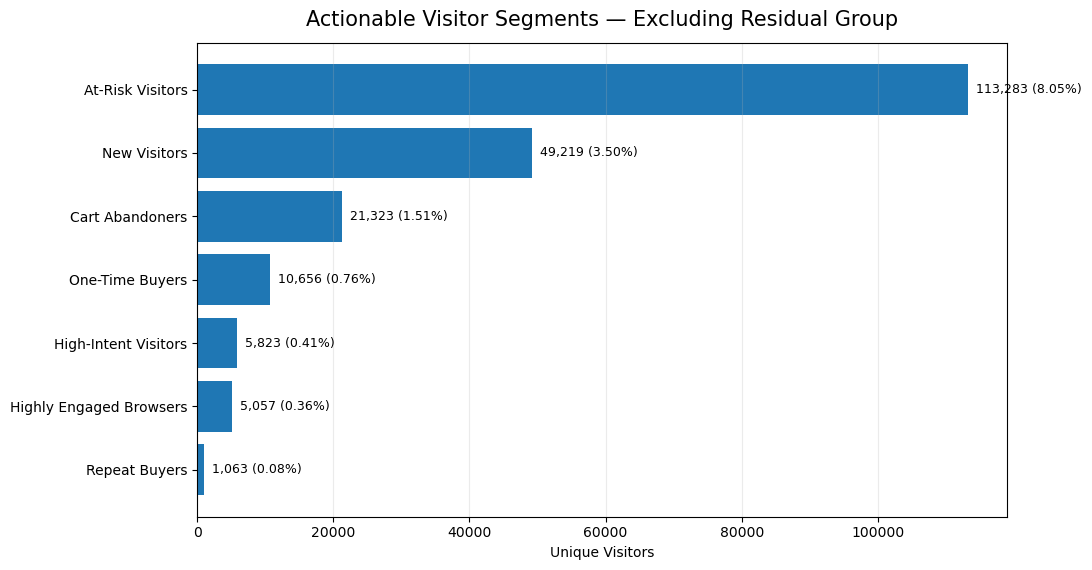

Saved figure: D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\figures\06_actionable_segment_distribution.png


In [12]:
# ============================================================
# CELL 10B — ACTIONABLE SEGMENT DISTRIBUTION
# ============================================================

# "Other Visitors" is retained in the analytical output, but excluded here
# so the smaller actionable segments remain visually interpretable.
actionable_segments = segment_counts.loc[
    segment_counts["segment"] != "Other Visitors"
].sort_values("visitors", ascending=True)

plt.figure(figsize=(11, 5.8))
bars = plt.barh(
    actionable_segments["segment"],
    actionable_segments["visitors"]
)

plt.title("Actionable Visitor Segments — Excluding Residual Group", fontsize=15, pad=12)
plt.xlabel("Unique Visitors")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)

for bar, (_, row) in zip(bars, actionable_segments.iterrows()):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {int(row['visitors']):,} ({row['share_pct']:.2f}%)",
        va="center",
        fontsize=9
    )

plt.tight_layout()
actionable_path = FIGURES_PATH / "06_actionable_segment_distribution.png"
plt.savefig(actionable_path, dpi=250, bbox_inches="tight")
plt.show()
print("Saved figure:", actionable_path)


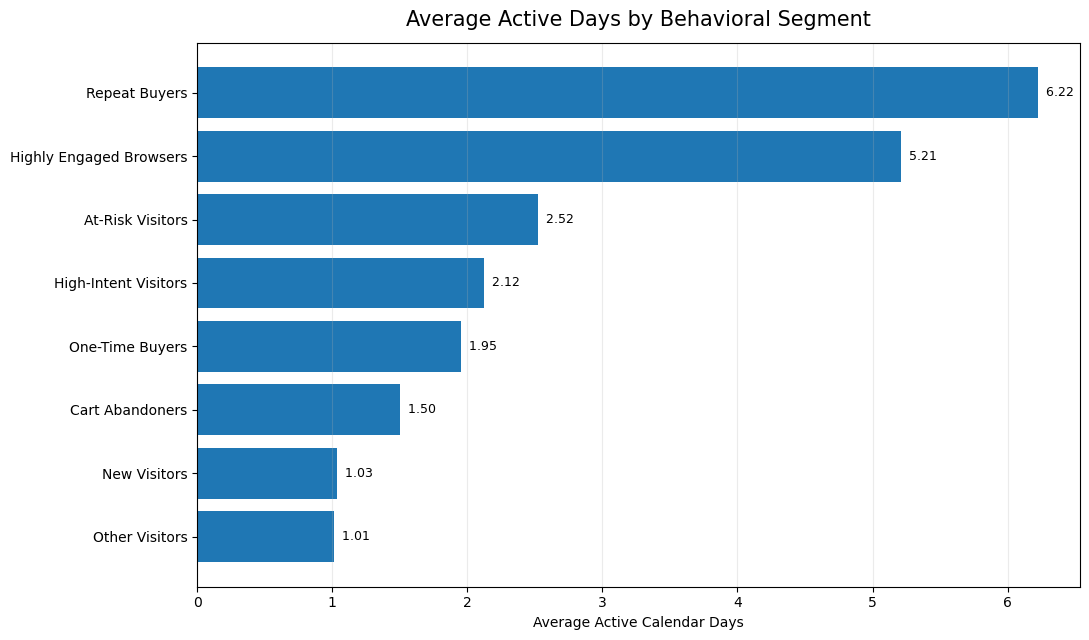

Saved figure: D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\figures\06_segment_engagement.png


In [13]:
# ============================================================
# CELL 11 — ENGAGEMENT PROFILE VISUALIZATION
# ============================================================

plot_profile = (
    segment_profile
    .dropna(subset=["visitors"])
    .sort_values("avg_active_days")
)

plt.figure(figsize=(11, 6.5))
plt.barh(
    plot_profile.index,
    plot_profile["avg_active_days"]
)

plt.title("Average Active Days by Behavioral Segment", fontsize=15, pad=12)
plt.xlabel("Average Active Calendar Days")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)

for y, value in enumerate(plot_profile["avg_active_days"]):
    if pd.notna(value) and value > 0:
        plt.text(
            value,
            y,
            f"  {value:.2f}",
            va="center",
            fontsize=9
        )

plt.tight_layout()

engagement_path = FIGURES_PATH / "06_segment_engagement.png"
plt.savefig(engagement_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved figure:", engagement_path)


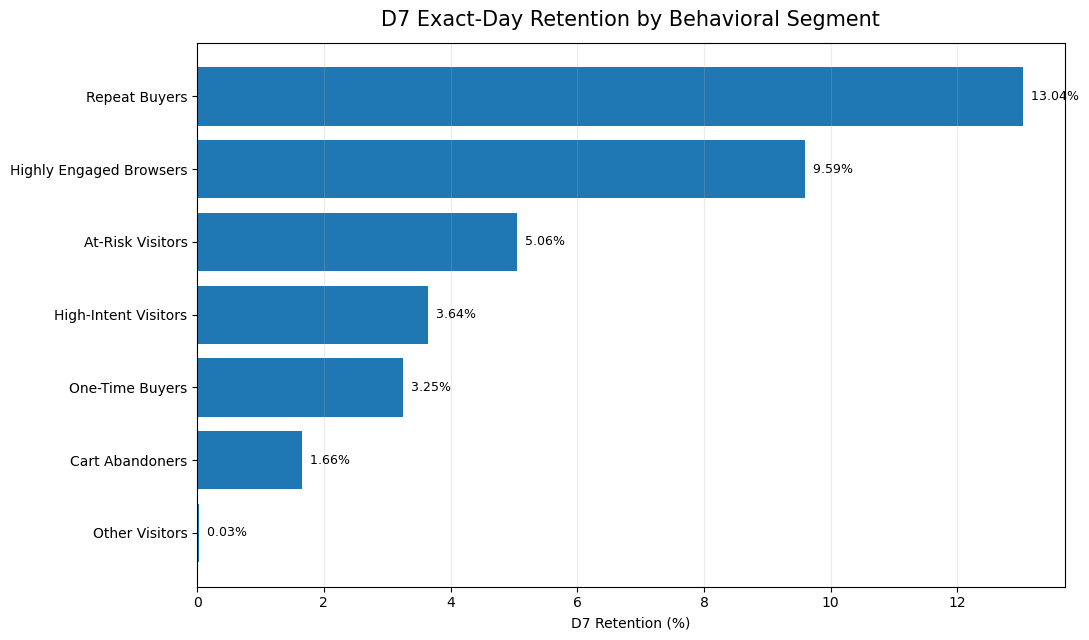

Saved figure: D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\figures\06_segment_d7_retention.png


In [14]:
# ============================================================
# CELL 12 — D7 SEGMENT RETENTION VISUALIZATION
# ============================================================

d7_plot = (
    segment_retention_summary["D7_retention_pct"]
    .dropna()
    .sort_values()
)

plt.figure(figsize=(11, 6.5))
plt.barh(
    d7_plot.index,
    d7_plot.values
)

plt.title("D7 Exact-Day Retention by Behavioral Segment", fontsize=15, pad=12)
plt.xlabel("D7 Retention (%)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)

for y, value in enumerate(d7_plot.values):
    if pd.notna(value):
        plt.text(
            value,
            y,
            f"  {value:.2f}%",
            va="center",
            fontsize=9
        )

plt.tight_layout()

d7_path = FIGURES_PATH / "06_segment_d7_retention.png"
plt.savefig(d7_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved figure:", d7_path)


## 7. Opportunity Signals

This section does **not** claim causality. It surfaces measurable behavioral signals for the eventual Growth Opportunity Engine.

Examples:
- large cart-abandoner population
- highly engaged browsers with low purchase progression
- segments with materially different D7 retention
- segments with high activity but weak conversion

The application can later combine these signals with product/category analysis.


In [15]:
# ============================================================
# CELL 13 — SEGMENT OPPORTUNITY SIGNALS
# ============================================================

# Large segments are defined relative to the observed population.
large_segment_threshold = len(vf) * 0.05

opportunity_rows = []

for segment in segment_order:

    row = segment_profile.loc[segment]
    funnel = segment_funnel.loc[segment]

    if row["visitors"] == 0:
        continue

    signals = []

    # Material visitor population.
    if row["visitors"] >= large_segment_threshold:
        signals.append("material visitor population")

    # Segment-specific behavioral opportunities.
    if segment == "Cart Abandoners":
        signals.append("cart activity without transaction")

    if segment == "High-Intent Visitors":
        signals.append("higher cart intent without transaction")

    if segment == "Highly Engaged Browsers":
        signals.append("repeated browsing without cart/transaction")

    if segment == "At-Risk Visitors":
        signals.append("recent inactivity after repeat-day behavior")

    # Low transaction participation within the segment.
    transaction_rate = funnel["transaction_participation_pct"]

    if pd.notna(transaction_rate) and transaction_rate < 1:
        signals.append("low transaction participation")

    # Low D7 retention where D7 is measurable.
    d7 = segment_retention_summary.loc[
        segment,
        "D7_retention_pct"
    ]

    if pd.notna(d7) and d7 < 1:
        signals.append("low D7 exact-day retention")

    if signals:
        opportunity_rows.append({
            "segment": segment,
            "visitors": int(row["visitors"]),
            "signals": "; ".join(signals)
        })


opportunity_signals = pd.DataFrame(
    opportunity_rows,
    columns=["segment", "visitors", "signals"]
)

print("SEGMENT OPPORTUNITY SIGNALS")
print("=" * 95)

if opportunity_signals.empty:
    print(
        "No predefined opportunity signal crossed "
        "the current evidence thresholds."
    )
else:
    print(opportunity_signals.to_string(index=False))

SEGMENT OPPORTUNITY SIGNALS
                segment  visitors                                                                                                 signals
   High-Intent Visitors      5823                                   higher cart intent without transaction; low transaction participation
        Cart Abandoners     21323                                        cart activity without transaction; low transaction participation
       At-Risk Visitors    113283 material visitor population; recent inactivity after repeat-day behavior; low transaction participation
           New Visitors     49219                                                                           low transaction participation
Highly Engaged Browsers      5057                               repeated browsing without cart/transaction; low transaction participation
         Other Visitors   1201156                  material visitor population; low transaction participation; low D7 exact-day retention


In [16]:
# ============================================================
# CELL 14 — FINAL VALIDATION CHECKS
# ============================================================

checks = {}

# ------------------------------------------------------------
# 1. Visitor population reconciles
# ------------------------------------------------------------

checks["visitor_population_reconciles"] = (
    segment_counts["visitors"].sum() == len(vf)
)

# ------------------------------------------------------------
# 2. Exactly one segment per visitor
# ------------------------------------------------------------

checks["one_segment_per_visitor"] = (
    vf["visitorid"].nunique() == len(vf)
)

# ------------------------------------------------------------
# 3. No missing segment labels
# ------------------------------------------------------------

checks["no_missing_segments"] = (
    vf["segment"].notna().all()
)

# ------------------------------------------------------------
# 4. Only expected segment labels
# ------------------------------------------------------------

checks["only_expected_segments"] = (
    set(vf["segment"].unique()).issubset(
        set(segment_order)
    )
)

# ------------------------------------------------------------
# 5. Transaction events have transaction IDs
# ------------------------------------------------------------

checks["transaction_events_have_ids"] = (
    events.loc[
        events["event"].eq("transaction"),
        "transactionid"
    ]
    .notna()
    .all()
)

# ------------------------------------------------------------
# 6. Behavioral features are non-negative
# ------------------------------------------------------------

numeric_feature_cols = [
    "active_days",
    "total_events",
    "view_events",
    "cart_events",
    "transaction_events",
    "unique_products_viewed",
    "unique_products_carted",
    "unique_products_purchased",
    "unique_transactions",
    "recency_days"
]

checks["non_negative_behavioral_features"] = (
    (vf[numeric_feature_cols] >= 0).all().all()
)

# ------------------------------------------------------------
# 7. Buyers actually have transactions
# ------------------------------------------------------------

checks["buyers_have_transactions"] = (
    vf.loc[
        vf["segment"].isin(
            ["Repeat Buyers", "One-Time Buyers"]
        ),
        "unique_transactions"
    ]
    .gt(0)
    .all()
)

# ------------------------------------------------------------
# 8. Non-buyers have no transaction events
# ------------------------------------------------------------

checks["non_buyers_have_no_transaction_events"] = (
    vf.loc[
        ~vf["segment"].isin(
            ["Repeat Buyers", "One-Time Buyers"]
        ),
        "transaction_events"
    ]
    .eq(0)
    .all()
)

# ------------------------------------------------------------
# 9. Cart segments have cart activity
# ------------------------------------------------------------

checks["cart_segments_have_cart_activity"] = (
    vf.loc[
        vf["segment"].isin(
            ["High-Intent Visitors", "Cart Abandoners"]
        ),
        "cart_events"
    ]
    .gt(0)
    .all()
)

# ------------------------------------------------------------
# 10. Funnel percentages are valid
# ------------------------------------------------------------

funnel_rate_cols = [
    "view_participation_pct",
    "cart_participation_pct",
    "transaction_participation_pct"
]

funnel_values = segment_funnel[funnel_rate_cols].to_numpy(
    dtype=float
)

finite_funnel = funnel_values[~np.isnan(funnel_values)]

checks["funnel_rates_valid"] = (
    len(finite_funnel) == 0 or
    (
        (finite_funnel >= 0) &
        (finite_funnel <= 100)
    ).all()
)

# ------------------------------------------------------------
# 11. Retention percentages are valid
# ------------------------------------------------------------

retention_values = (
    segment_retention_summary
    .to_numpy(dtype=float)
)

finite_retention = retention_values[
    ~np.isnan(retention_values)
]

checks["retention_rates_valid"] = (
    len(finite_retention) == 0 or
    (
        (finite_retention >= 0) &
        (finite_retention <= 100)
    ).all()
)

# ------------------------------------------------------------
# 12. Retained visitors never exceed eligible visitors
# ------------------------------------------------------------

checks["retained_never_exceeds_eligible"] = all(
    (
        table["retained_visitors"]
        <= table["eligible_visitors"]
    )
    .fillna(True)
    .all()
    for table in segment_retention_tables.values()
)

# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print("FINAL VALIDATION")
print("=" * 75)

for check_name, passed in checks.items():

    print(
        f"{check_name.replace('_', ' ').title()}: "
        f"{'PASSED' if passed else 'FAILED'}"
    )

# ------------------------------------------------------------
# Portfolio gate
# ------------------------------------------------------------

if not all(checks.values()):

    failed_checks = [
        name
        for name, passed in checks.items()
        if not passed
    ]

    raise AssertionError(
        "Validation failed: "
        + ", ".join(failed_checks)
    )

print("\nALL PORTFOLIO VALIDATION CHECKS PASSED")

FINAL VALIDATION
Visitor Population Reconciles: PASSED
One Segment Per Visitor: PASSED
No Missing Segments: PASSED
Only Expected Segments: PASSED
Transaction Events Have Ids: PASSED
Non Negative Behavioral Features: PASSED
Buyers Have Transactions: PASSED
Non Buyers Have No Transaction Events: PASSED
Cart Segments Have Cart Activity: PASSED
Funnel Rates Valid: PASSED
Retention Rates Valid: PASSED
Retained Never Exceeds Eligible: PASSED

ALL PORTFOLIO VALIDATION CHECKS PASSED


In [17]:
# ============================================================
# CELL 15 — EXPORT PORTFOLIO OUTPUTS
# ============================================================

segment_counts.to_csv(
    OUTPUTS_PATH / "06_segment_distribution.csv",
    index=False
)

segment_profile.reset_index().to_csv(
    OUTPUTS_PATH / "06_segment_profile.csv",
    index=False
)

segment_funnel.reset_index().to_csv(
    OUTPUTS_PATH / "06_segment_funnel.csv",
    index=False
)

segment_retention_summary.reset_index().rename(
    columns={"index": "segment"}
).to_csv(
    OUTPUTS_PATH / "06_segment_retention.csv",
    index=False
)

segment_rulebook.to_csv(
    OUTPUTS_PATH / "06_segment_rulebook.csv",
    index=False
)

opportunity_signals.to_csv(
    OUTPUTS_PATH / "06_segment_opportunity_signals.csv",
    index=False
)

vf.to_csv(
    OUTPUTS_PATH / "06_visitor_segment_features.csv",
    index=False
)

print("PORTFOLIO OUTPUTS EXPORTED")
print("=" * 70)

for file_name in [
    "06_segment_distribution.csv",
    "06_segment_profile.csv",
    "06_segment_funnel.csv",
    "06_segment_retention.csv",
    "06_segment_rulebook.csv",
    "06_segment_opportunity_signals.csv",
    "06_visitor_segment_features.csv"
]:
    print(OUTPUTS_PATH / file_name)


PORTFOLIO OUTPUTS EXPORTED
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\06_segment_distribution.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\06_segment_profile.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\06_segment_funnel.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\06_segment_retention.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\06_segment_rulebook.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\06_segment_opportunity_signals.csv
D:\Data science portfolio\03_Product_Growth_Intelligence\outputs\06_visitor_segment_features.csv


## 9. Final Business Interpretation

### What this notebook establishes

The segmentation layer converts raw event behavior into **auditable visitor-level behavioral groups**.

- **Repeat Buyers** identify visitors with multiple observed transactions.
- **One-Time Buyers** identify visitors who converted once.
- **High-Intent Visitors** identify non-buyers with stronger cart activity.
- **Cart Abandoners** identify visitors who added items to cart but did not transact.
- **At-Risk Visitors** identify previously returning non-buyers with prolonged inactivity.
- **New Visitors** identify recent entrants into the observed product ecosystem.
- **Highly Engaged Browsers** identify non-buyers with repeated activity and stronger browsing depth.
- **Other Visitors** capture remaining behavior not covered by the primary rules.

### How this feeds the Product & Growth Intelligence Platform

The outputs form a reusable analytical layer:

**Funnel → Retention → User Segments → Product/Category Intelligence → Growth Opportunity Engine → Streamlit Application**

The exported CSVs and figures are designed to feed the later application without repeating the visitor-level feature engineering.

### Analytical limitations

These labels are **descriptive behavioral constructs**. They do not establish causality and do not represent:
- demographic attributes
- acquisition source
- revenue or profit
- session boundaries
- experimental assignment
- predicted future churn

`At-Risk Visitors` is an inactivity signal, **not a churn model**.

### Reproducibility

Run the notebook from a clean kernel using **Kernel → Restart Kernel and Run All**. The thresholds are calculated from the observed population each time, while minimum guardrails prevent degenerate segment definitions.


---

### Notebook 06 — Final Status

**Purpose:** Behavioral segmentation and engagement intelligence.

**Method:** Transparent, mutually exclusive, rule-based visitor segmentation using observed behavioral thresholds and minimum guardrails.

**Primary outputs:**
- visitor behavioral feature table
- segment distribution and actionable-segment view
- segment profiles
- segment funnel metrics
- D1/D7/D30 exact-day retention comparisons
- segment opportunity signals
- portfolio-ready figures
- validation checks
- reusable CSV exports

**Important interpretation rule:** Segment labels are descriptive behavioral constructs based on the full observation window. Segment-level retention is therefore a **retrospective comparison**, not a prediction of future retention or churn.

**Feeds next module:** Product & Category Intelligence → Growth Opportunity Engine → Streamlit application.

**Dataset boundary:** This notebook uses only reliable fields from `events.csv` and does not invent revenue, demographics, acquisition channels, sessions, or experimental assignment.


---

## Portfolio Lock

This notebook is the finalized version for Portfolio Project 3. Run it from a clean kernel using **Kernel → Restart Kernel and Run All**. The validation gate must finish with **ALL PORTFOLIO VALIDATION CHECKS PASSED** before committing the notebook and exported outputs to GitHub.

**Do not modify the analytical rules, thresholds, funnel definitions, retention methodology, or validation logic after the final clean run.**